# Linear-in-means network game — adversarial structural estimation

This notebook estimates the **linear-in-means** social-interactions model with the
`adversarial_networks` engine. The model is the canonical linear social-spillover
equilibrium

$$ Y \;=\; \beta\, W Y \;+\; \gamma\, X \;+\; \varepsilon, \qquad \varepsilon \sim \mathcal N(0,\sigma^2 I), $$

where $W$ is the **row-stochastic** neighbour-averaging operator ($W_{ij}=1/\deg(i)$ for
$j$ a neighbour of $i$), so $(WY)_i$ is the *average* outcome of $i$'s peers. With
$|\beta|<1$ the map $Y\mapsto \beta WY + \gamma X + \varepsilon$ is a contraction and the
equilibrium $Y=(I-\beta W)^{-1}(\gamma X+\varepsilon)$ is unique. The structural
parameters are the peer-effect $\beta$, the exogenous loading $\gamma$, and the shock
variance $\sigma^2$.

### The adversarial estimator in one paragraph
The generator is the structural model itself: given $\theta=(\beta,\gamma,\sigma^2)$ it
*simulates* an equilibrium $Y^\theta$ on the observed graph. A **discriminator** (a
root-aware GNN, `RootedMPNNDiscriminator`) is trained to tell real rooted ego-subgraphs
(built from the observed $Y$) from fake ones (built from $Y^\theta$). The estimator plays
the GAN minimax: the discriminator maximises its classification objective while the
structural parameters move to *fool* it. At the population optimum the discriminator is
maximally confused ($D\equiv\tfrac12$): its loss sits at $2\log 2$ and the
(non-saturating) structural loss at $\log 2$, and $\theta$ matches the data-generating
truth. This is `AdversarialEstimator` — a single, model-agnostic, sklearn-shaped object
(`.fit(data)` → trailing-underscore learned attributes).

> **Scale note.** Everything below runs at a deliberately *small* scale (2000 nodes,
> 300 steps) so the notebook finishes in well under two minutes. At this scale the
> pipeline **runs and the parameters move toward the truth**, but clean
> within-tolerance recovery needs a large graph and a longer schedule — see the
> commented *paper-scale* recipe at the end.

In [1]:
import warnings
import math

import numpy as np
import torch
import matplotlib.pyplot as plt

import adversarial_networks as an
from adversarial_networks.config import InstanceNoiseConfig
from adversarial_networks.observability import ConsoleLogger
from adversarial_networks.core.objective import OPTIMAL_DISC_LOSS, OPTIMAL_GEN_LOSS

torch.manual_seed(0)
np.random.seed(0)

print("adversarial_networks", an.__version__)
print("OPTIMAL_DISC_LOSS = 2 log 2 =", round(OPTIMAL_DISC_LOSS, 4))
print("OPTIMAL_GEN_LOSS  =   log 2 =", round(OPTIMAL_GEN_LOSS, 4))

adversarial_networks 0.1.0
OPTIMAL_DISC_LOSS = 2 log 2 = 1.3863
OPTIMAL_GEN_LOSS  =   log 2 = 0.6931


## 1. Synthetic data

`make_linear_in_means` builds a graph, draws covariates $X$, and simulates the observed
equilibrium $Y$ from the built-in `LinearInMeansGenerator` at the known true parameters
$\{\beta=0.4,\ \gamma=1.5,\ \sigma^2=1.0\}$. We use a small Barabasi-Albert graph (`m=2`)
so the notebook is fast.

In [2]:
TRUE_PARAMS = {"beta": 0.4, "gamma": 1.5, "sigma_sq": 1.0}

data = an.make_linear_in_means(n_nodes=2000, graph="ba", k=2, seed=0, m=2)
print(data)
print("num_nodes:", data.num_nodes, "| ego radius k:", data.k)
print("observed y:  mean=%.3f  std=%.3f" % (data.y.mean().item(), data.y.std().item()))

NetworkData(num_nodes=2000, k=2, device=cpu)
num_nodes: 2000 | ego radius k: 2
observed y:  mean=0.044  std=1.973


## 2. Admissibility check

Before estimating we verify the **true model is admissible on this network**:
`check_model` drives the equilibrium through the model's hooks (with one fixed shock
draw) and checks the contraction modulus (operator $\infty$-norm of the best-response
Jacobian, must be $<1$), locality, shock monotonicity, fixed-point uniqueness, the
equilibrium residual, and that gradients reach every learnable parameter. A truthy report
means the model is well-posed for the estimator.

In [3]:
model = an.LinearInMeansGenerator(beta_cap=0.85)

report = an.check_model(model, data, n_probe=200)
print(report)
assert report, "true model must be admissible before estimating"
print("\ncontraction_modulus =", round(report["contraction_modulus"].value, 4), "(< 1 required)")

ModelReport
  equilibrium_residual            0  (thr 0.001)  PASS
  contraction_modulus             0  (thr 1)  PASS   operator inf-norm max_i sum_j|dB_i/dY_j|
  locality_A2                     0  (thr 0.0001)  PASS   max |dB_i/dY_j|, j not in 1-hop(i)
  shock_monotone_U4               1  (thr 0)  PASS   min dB_i/d eps_i
  uniqueness                      0  (thr 0.0001)  PASS   multi-start Picard agreement
  gradients                       3  (thr 3)  PASS   3/3 learnable params reached; all finite=True
  => PASS

contraction_modulus = 0.0 (< 1 required)


## 3. Fit the adversarial estimator

We attach an annealed **instance-noise blur** to the discriminator inputs — the standard
GAN-on-continuous-data stabiliser (the blur std anneals to a small floor over training).
A `ConsoleLogger` prints periodic progress. The estimator deep-copies the model and
discriminator (the constructor objects stay pristine), runs the alternating minimax to its
stopping rule or `max_steps`, and returns `self`.

In [ ]:
disc = an.RootedMPNNDiscriminator(hidden_dim=12, num_layers=2, logit_clip=4.0)

cfg = an.EstimatorConfig(
    max_steps=300, min_steps=0, batch_size=16, n_disc=1,
    lr_d=2e-4, lr_g=3e-3, seed=0,
    convergence_window=100, stability_window=30,
)

blur = InstanceNoiseConfig(
    enabled=True, tau_y0=1.0, schedule="linear",
    anneal_steps=180, min_tau=0.0,   # blur anneals to 0 by step 180, before the tail-averaging window (tail starts at step 201)
)

est = an.AdversarialEstimator(
    model, disc, config=cfg, instance_noise=blur,
    observers=[ConsoleLogger(every_n_steps=100, prefix="lim")],
)

# Non-convergence at this tiny scale is expected and surfaces as a warning, not an error.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    est.fit(data)

print("\nconverged:", est.converged_, "| steps run:", est.n_iter_)
print("rolling losses  D=%.4f (target %.4f)   G=%.4f (target %.4f)"
      % (est.loss_d_, OPTIMAL_DISC_LOSS, est.loss_g_, OPTIMAL_GEN_LOSS))

## 4. Estimates and recovery table

`estimates_` reports the tail-averaged coefficient (`coef`), the last iterate (`final`),
and the optimisation-path spread (`path_sd` — a *convergence diagnostic, not a standard
error*). `recovery_table` lines those up against the data-generating truth with the
absolute error.

In [5]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    estimates = est.estimates_
    recovery = est.recovery_table(TRUE_PARAMS)

print("estimates_:")
print(estimates.round(4))
print("\nrecovery_table:")
print(recovery.round(4))

estimates_:
            coef   final  path_sd
param                            
beta      0.2638  0.4618   0.1171
gamma     0.6851  0.9915   0.1829
sigma_sq  1.8471  2.3936   0.3054

recovery_table:
            coef  true  abs_err  path_sd
param                                   
beta      0.2638   0.4   0.1362   0.1171
gamma     0.6851   1.5   0.8149   0.1829
sigma_sq  1.8471   1.0   0.8471   0.3054


**Reading this honestly.** At 2000 nodes / 300 steps the parameters have *moved off
their initialisation toward the truth* (e.g. $\beta$ and $\gamma$ climb from 0), but they
are not yet within a tight tolerance and the rolling losses have not settled onto
$2\log2$ / $\log2$. That is the expected fast-scale behaviour. The paper-scale recipe at
the bottom (10k+ nodes, the calibrated `recovery_default()` schedule) is what recovers the
parameters within tolerance.

## 5. Diagnostics

Four standard views of the run, all driven from `est.history_` (an `InMemoryHistory`
observer that recorded every step):

* **(a) Loss curves** vs the population-optimum constants $2\log2$ and $\log2$.
* **(b) Parameter paths** vs the true values (dashed).
* **(c) Simulated-vs-observed** outcomes at the estimated $\theta$.
* **(d) Discriminator score histograms** — real vs fake $\sigma(\text{logit})$; at a good
  fit the two clouds overlap around 0.5 (the discriminator is fooled).

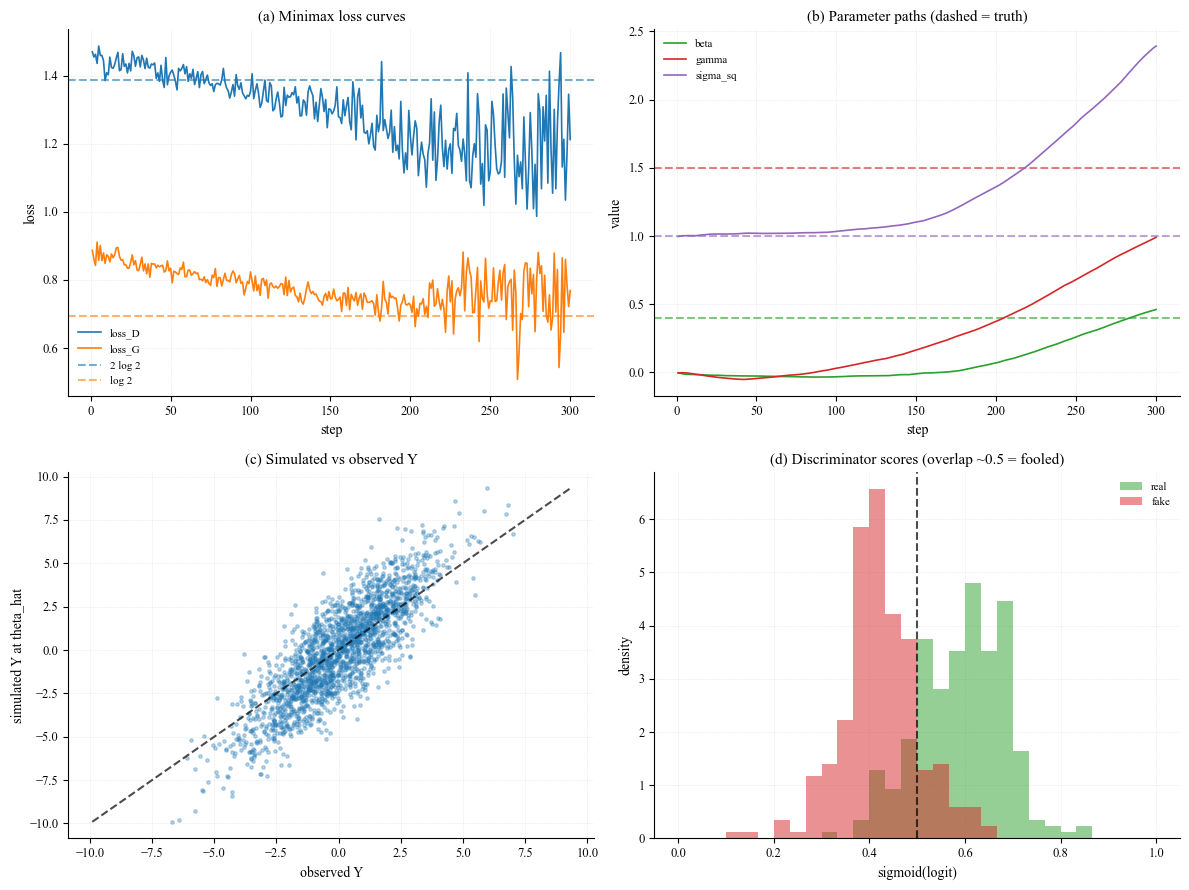

score means: real=0.594  fake=0.423


In [6]:
hist = est.history_
steps = np.asarray(hist.steps)
loss_d = np.asarray(hist.loss_d)
loss_g = np.asarray(hist.loss_g)
paths = hist.param_history()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    y_sim = est.simulate(seed=1).cpu().numpy()
    real_scores, fake_scores = est.discriminator_scores(n_roots=256)
y_obs = data.y.cpu().numpy()
real_scores = real_scores.cpu().numpy()
fake_scores = fake_scores.cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# (a) loss curves
ax = axes[0, 0]
ax.plot(steps, loss_d, label="loss_D", color="tab:blue", lw=1.2)
ax.plot(steps, loss_g, label="loss_G", color="tab:orange", lw=1.2)
ax.axhline(OPTIMAL_DISC_LOSS, ls="--", color="tab:blue", alpha=0.6, label="2 log 2")
ax.axhline(OPTIMAL_GEN_LOSS, ls="--", color="tab:orange", alpha=0.6, label="log 2")
ax.set_title("(a) Minimax loss curves")
ax.set_xlabel("step"); ax.set_ylabel("loss"); ax.legend(fontsize=8)

# (b) parameter paths
ax = axes[0, 1]
colors = {"beta": "tab:green", "gamma": "tab:red", "sigma_sq": "tab:purple"}
for name, path in paths.items():
    c = colors.get(name, "tab:gray")
    ax.plot(steps, path, label=name, color=c, lw=1.2)
    if name in TRUE_PARAMS:
        ax.axhline(TRUE_PARAMS[name], ls="--", color=c, alpha=0.6)
ax.set_title("(b) Parameter paths (dashed = truth)")
ax.set_xlabel("step"); ax.set_ylabel("value"); ax.legend(fontsize=8)

# (c) sim vs obs
ax = axes[1, 0]
ax.scatter(y_obs, y_sim, s=6, alpha=0.3, color="tab:blue")
lim = [min(y_obs.min(), y_sim.min()), max(y_obs.max(), y_sim.max())]
ax.plot(lim, lim, ls="--", color="black", alpha=0.7)
ax.set_title("(c) Simulated vs observed Y")
ax.set_xlabel("observed Y"); ax.set_ylabel("simulated Y at theta_hat")

# (d) discriminator scores
ax = axes[1, 1]
bins = np.linspace(0, 1, 31)
ax.hist(real_scores, bins=bins, alpha=0.5, label="real", color="tab:green", density=True)
ax.hist(fake_scores, bins=bins, alpha=0.5, label="fake", color="tab:red", density=True)
ax.axvline(0.5, ls="--", color="black", alpha=0.7)
ax.set_title("(d) Discriminator scores (overlap ~0.5 = fooled)")
ax.set_xlabel("sigmoid(logit)"); ax.set_ylabel("density"); ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

print("score means: real=%.3f  fake=%.3f" % (real_scores.mean(), fake_scores.mean()))

## 6. Paper-scale recipe (not executed)

The cell below is the **real-scale** recipe. It is intentionally left as a non-executed
code block so this notebook stays fast. It uses a large Barabasi-Albert graph, the
calibrated `EstimatorConfig.recovery_default()` schedule (batch 17, decaying LR, the
loss-band + parameter-stability stopping rule), and an outcome blur annealed to zero over
1000 of the 1200 steps (so the last ~200 steps run at sigma=0 and the estimator targets
the original, unblurred criterion). This is the configuration that recovers $\beta$ and
$\gamma$ within tolerance across seeds.

```python
# --- PAPER SCALE (run on a machine with a few minutes to spare) ---------------
import adversarial_networks as an
from adversarial_networks.config import InstanceNoiseConfig
from adversarial_networks.observability import ConsoleLogger

TRUE_PARAMS = {"beta": 0.4, "gamma": 1.5, "sigma_sq": 1.0}

data = an.make_linear_in_means(n_nodes=10_000, graph="ba", k=2, seed=0, m=2)

model = an.LinearInMeansGenerator(beta_cap=0.85)
assert an.check_model(model, data)

disc = an.RootedMPNNDiscriminator(hidden_dim=12, num_layers=2, logit_clip=4.0)
cfg  = an.EstimatorConfig.recovery_default()          # batch 17, decaying LR, full stopping rule
blur = InstanceNoiseConfig(enabled=True, tau_y0=1.0,
                           schedule="linear", anneal_steps=1000, min_tau=0.0)

est = an.AdversarialEstimator(
    model, disc, config=cfg, instance_noise=blur,
    observers=[ConsoleLogger(every_n_steps=100, prefix="paper")],
).fit(data)

print(est.recovery_table(TRUE_PARAMS).round(4))   # beta, gamma recovered within tolerance
```